In [1]:
from google.colab import files
uploaded = files.upload()

Saving HeartDiseaseTrain-Test.csv to HeartDiseaseTrain-Test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [3]:
df = pd.read_csv("HeartDiseaseTrain-Test.csv")
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [4]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia           

In [5]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholestoral,0
fasting_blood_sugar,0
rest_ecg,0
Max_heart_rate,0
exercise_induced_angina,0
oldpeak,0


In [6]:
df["target"].value_counts()

,count
target,
1,526
0,499


In [7]:
print("Original dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Dataset shape after duplicate removal:", df.shape)

Original dataset shape: (1025, 14)
Duplicate rows: 723
Dataset shape after duplicate removal: (302, 14)


In [8]:
df["target"].value_counts()

,count
target,
1,164
0,138


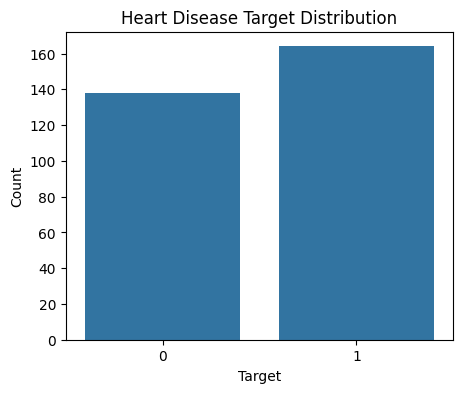

In [9]:
plt.figure(figsize=(5, 4))
sns.countplot(x="target", data=df)
plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [10]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (302, 13)
Target shape: (302,)


In [11]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']
Numeric columns: ['age', 'resting_blood_pressure', 'cholestoral', 'Max_heart_rate', 'oldpeak']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (241, 13)
Testing data: (61, 13)


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [14]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),

    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(probability=True, random_state=42))
    ])
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

    print(f"\n{name}")
    print("-" * 50)
    print(classification_report(y_test, y_pred))


Logistic Regression
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61


Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61


SVM
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80

In [15]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.836066,0.848485,0.848485,0.848485
Random Forest,0.786885,0.812500,0.787879,0.800000
SVM,0.786885,0.812500,0.787879,0.800000


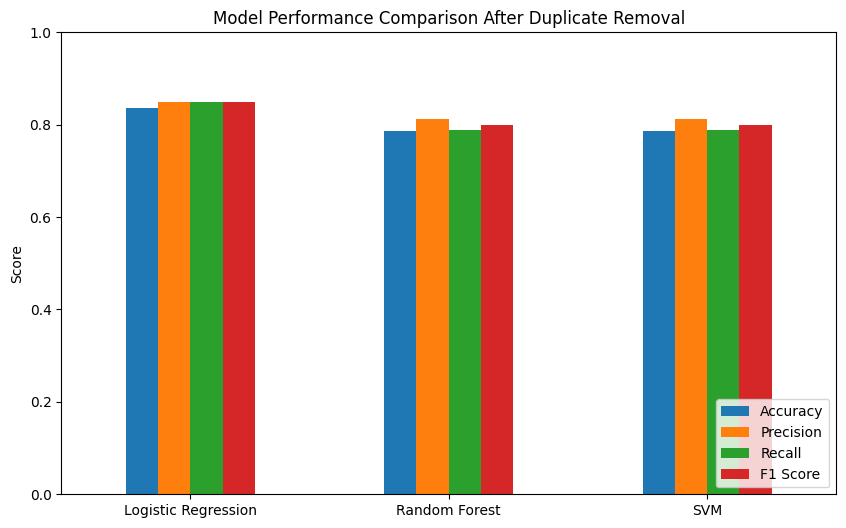

In [16]:
results_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison After Duplicate Removal")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

In [17]:
best_model_name = results_df["F1 Score"].idxmax()
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print(results_df.loc[best_model_name])

Best Model: Logistic Regression
Accuracy     0.836066
Precision    0.848485
Recall       0.848485
F1 Score     0.848485
Name: Logistic Regression, dtype: float64


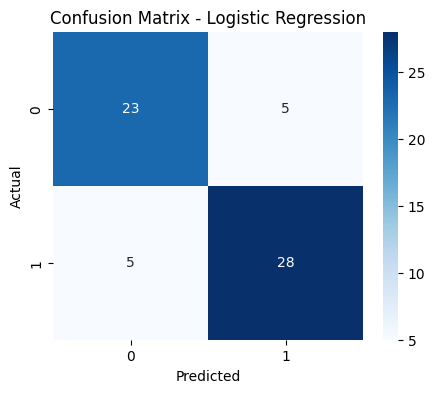

In [18]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
sample_patient = X_test.iloc[[0]]

prediction = best_model.predict(sample_patient)[0]
prediction_probability = best_model.predict_proba(sample_patient)[0]

print("Sample Patient Data:")
display(sample_patient)

print("\nPrediction:", prediction)

if prediction == 1:
    print("Result: Higher risk of heart disease")
else:
    print("Result: Lower risk / no heart disease")

print("\nPrediction Probability:")
print("No Heart Disease:", prediction_probability[0])
print("Heart Disease:", prediction_probability[1])

Sample Patient Data:


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia
25,61,Female,Typical angina,145,307,Lower than 120 mg/ml,Normal,146,Yes,1.0,Flat,Zero,Reversable Defect



Prediction: 0
Result: Lower risk / no heart disease

Prediction Probability:
No Heart Disease: 0.7844332452849161
Heart Disease: 0.21556675471508396


In [20]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute Importance": abs(coefficients)
}).sort_values(by="Absolute Importance", ascending=False)

feature_importance.head(10)

,Feature,Coefficient,Absolute Importance
25,cat__vessels_colored_by_flourosopy_Zero,1.430413,1.430413
24,cat__vessels_colored_by_flourosopy_Two,-1.291609,1.291609
10,cat__chest_pain_type_Typical angina,-1.215932,1.215932
5,cat__sex_Female,0.813260,0.813260
3,num__Max_heart_rate,0.802284,0.802284
6,cat__sex_Male,-0.790919,0.790919
7,cat__chest_pain_type_Asymptomatic,0.749456,0.749456
29,cat__thalassemia_Reversable Defect,-0.730525,0.730525
21,cat__vessels_colored_by_flourosopy_Four,0.698197,0.698197
9,cat__chest_pain_type_Non-anginal pain,0.686816,0.686816


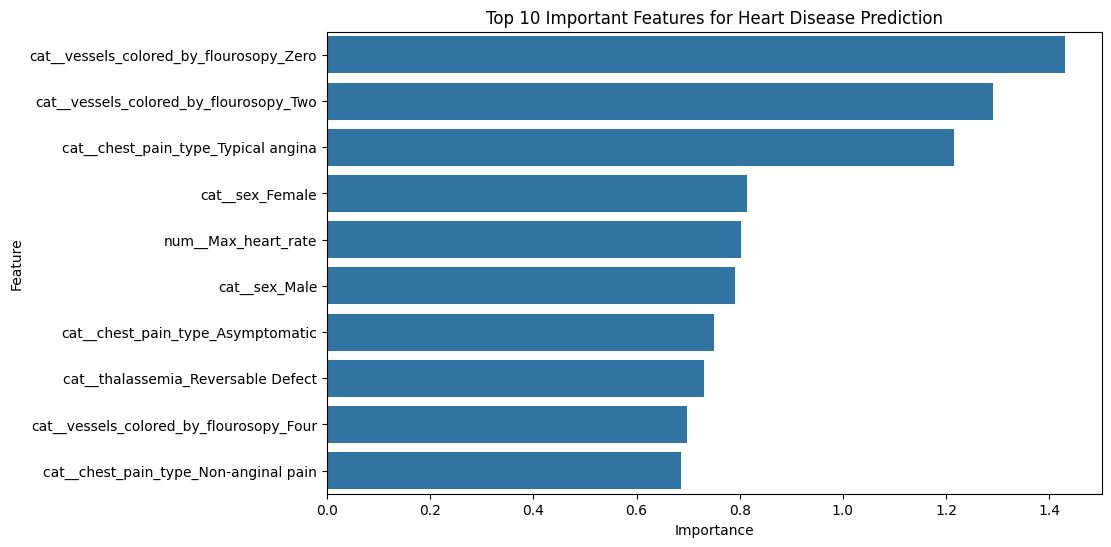

In [21]:
top_features = feature_importance.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Absolute Importance",
    y="Feature",
    data=top_features
)
plt.title("Top 10 Important Features for Heart Disease Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [22]:
joblib.dump(best_model, "heart_disease_model.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")
joblib.dump(results_df, "model_results.pkl")

print("Model, feature names, and results saved successfully.")

Model, feature names, and results saved successfully.
